In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

--- 1. SIMULATED DATA SETUP (Replace this section with your actual file loads) ---
Assuming you have a DataFrame 'df_nav' with columns: ['Date', 'Scheme_1', ..., 'Scheme_40', 'Nifty 50', 'Nifty 100']
And a DataFrame 'df_info' with columns: ['Scheme_Name', 'Expense_Ratio']

In [2]:
np.random.seed(42)
dates = pd.date_range(start="2021-06-01", end="2026-06-01", freq="B")
num_schemes = 40

In [3]:
# Generate dummy NAV data starting at 100 with random walks
nav_data = {"Date": dates}
for i in range(1, num_schemes + 1):
    nav_data[f"Scheme_{i}"] = 100 * np.exp(
        np.cumsum(np.random.normal(0.0005, 0.012, len(dates)))
    )

In [4]:
# Benchmarks
nav_data["Nifty 50"] = 100 * np.exp(
        np.cumsum(np.random.normal(0.0004, 0.010, len(dates)))
)
nav_data["Nifty 100"] = 100 * np.exp(
        np.cumsum(np.random.normal(0.00042, 0.011, len(dates)))
)

In [5]:
df_nav = pd.DataFrame(nav_data).set_index("Date")

In [6]:
# Expense ratios
df_info = pd.DataFrame({
    "Scheme_Name": [f"Scheme_{i}" for i in range(1, num_schemes + 1)],
    "Expense_Ratio": np.random.uniform(0.005, 0.025, num_schemes)  # 0.5% to 2.5%
})

In [7]:
# --- CONSTANTS ---
Rf_daily = 0.065 / 252
TRADING_DAYS = 252

In [8]:
# ==========================================
# TASK 1: Daily Returns & Distribution Check
# ==========================================
df_returns = df_nav.pct_change().dropna()

In [9]:
print("--- Daily Returns Distribution Validation ---")
print(df_returns[[f"Scheme_{i}" for i in range(1, 6)]].describe())

--- Daily Returns Distribution Validation ---
          Scheme_1     Scheme_2     Scheme_3     Scheme_4     Scheme_5
count  1304.000000  1304.000000  1304.000000  1304.000000  1304.000000
mean      0.001031     0.000888     0.000431     0.000196     0.000043
std       0.011878     0.011868     0.012116     0.011919     0.012132
min      -0.037667    -0.035103    -0.034775    -0.036922    -0.033713
25%      -0.007160    -0.006987    -0.008167    -0.007461    -0.008162
50%       0.001067     0.000583     0.000391     0.000431    -0.000246
75%       0.008449     0.008726     0.008513     0.008134     0.008450
max       0.047842     0.039581     0.048767     0.039069     0.038398


In [10]:
# ==========================================
# TASK 2: CAGR Calculation (1yr, 3yr, 5yr)
# ==========================================
cagr_results = []
schemes = [col for col in df_nav.columns if "Scheme" in col]

In [11]:
for fund in schemes:
    nav_series = df_nav[fund].dropna()
    nav_end = nav_series.iloc[-1]
    
    # Calculate intervals based on data availability
    cagr_dict = {"Scheme_Name": fund}
    for yrs in [1, 3, 5]:
        days_back = yrs * TRADING_DAYS
        if len(nav_series) >= days_back:
            nav_start = nav_series.iloc[-days_back]
            cagr = (nav_end / nav_start) ** (1 / yrs) - 1
        else:
            cagr = np.nan
        cagr_dict[f"CAGR_{yrs}Yr"] = cagr
    cagr_results.append(cagr_dict)

In [12]:
df_cagr = pd.DataFrame(cagr_results)

In [13]:
# ==========================================
# TASK 3 & 4: Sharpe & Sortino Ratios
# ==========================================
risk_adjusted_metrics = []

In [14]:
for fund in schemes:
    fund_ret = df_returns[fund]
    excess_ret = fund_ret - Rf_daily
    
    # Sharpe Ratio
    sharpe = (excess_ret.mean() / fund_ret.std()) * np.sqrt(TRADING_DAYS)
    
    # Sortino Ratio
    downside_ret = fund_ret[fund_ret < 0]
    downside_std = downside_ret.std()
    sortino = (excess_ret.mean() / downside_std) * np.sqrt(TRADING_DAYS) if downside_std > 0 else np.nan
    
    risk_adjusted_metrics.append({
        "Scheme_Name": fund,
        "Sharpe_Ratio": sharpe,
        "Sortino_Ratio": sortino
    })

In [15]:
df_risk_metrics = pd.DataFrame(risk_adjusted_metrics)

In [16]:
# ==========================================
# TASK 5: Alpha and Beta (vs Nifty 100)
# ==========================================
alpha_beta_results = []
benchmark_ret = df_returns["Nifty 100"]

In [17]:
for fund in schemes:
    fund_ret = df_returns[fund]
    beta, intercept, r_value, p_value, std_err = stats.linregress(benchmark_ret, fund_ret)
    alpha = intercept * TRADING_DAYS
    
    alpha_beta_results.append({
        "Scheme_Name": fund,
        "Alpha": alpha,
        "Beta": beta
    })

In [18]:
df_alpha_beta = pd.DataFrame(alpha_beta_results)
df_alpha_beta.to_csv("alpha_beta.csv", index=False)

In [19]:
# ==========================================
# TASK 6: Maximum Drawdown & Date Ranges
# ==========================================
mdd_results = []

In [20]:
for fund in schemes:
    nav_series = df_nav[fund]
    running_max = nav_series.cummax()
    drawdown = nav_series / running_max - 1
    max_dd = drawdown.min()
    
    # Locate date range
    end_date = drawdown.idxmin()
    # Find the peak before that specific valley
    start_date = nav_series.loc[:end_date].idxmax()
    
    mdd_results.append({
        "Scheme_Name": fund,
        "Max_Drawdown": max_dd,
        "DD_Start_Date": start_date.strftime('%Y-%m-%d'),
        "DD_End_Date": end_date.strftime('%Y-%m-%d')
    })

In [21]:
df_mdd = pd.DataFrame(mdd_results)

In [22]:
# ==========================================
# TASK 7: Fund Scorecard Creation (0-100)
# ==========================================
# Merge all generated tables together
df_scorecard = df_cagr.merge(df_risk_metrics, on="Scheme_Name") \
                      .merge(df_alpha_beta, on="Scheme_Name") \
                      .merge(df_mdd, on="Scheme_Name") \
                      .merge(df_info, on="Scheme_Name")

In [23]:
# Compute ranks (Higher standard values get better rank, lower inverse values get better rank)
df_scorecard['rank_3yr'] = df_scorecard['CAGR_3Yr'].rank(ascending=True)
df_scorecard['rank_sharpe'] = df_scorecard['Sharpe_Ratio'].rank(ascending=True)
df_scorecard['rank_alpha'] = df_scorecard['Alpha'].rank(ascending=True)
df_scorecard['rank_expense'] = df_scorecard['Expense_Ratio'].rank(ascending=False) # Inverse
df_scorecard['rank_mdd'] = df_scorecard['Max_Drawdown'].rank(ascending=True) # Max DD is negative, higher value means shallower drawdown

In [24]:
# Normalize ranks to a scale of 0 to 100
for col in ['rank_3yr', 'rank_sharpe', 'rank_alpha', 'rank_expense', 'rank_mdd']:
    df_scorecard[col] = (df_scorecard[col] - 1) / (num_schemes - 1) * 100

In [25]:
# Composite weighted scorecard
df_scorecard['Scorecard_Score'] = (
    0.30 * df_scorecard['rank_3yr'] +
    0.25 * df_scorecard['rank_sharpe'] +
    0.20 * df_scorecard['rank_alpha'] +
    0.15 * df_scorecard['rank_expense'] +
    0.10 * df_scorecard['rank_mdd']
)

In [26]:
# Sort by final score
df_scorecard = df_scorecard.sort_values(by="Scorecard_Score", ascending=False)
df_scorecard.to_csv("fund_scorecard.csv", index=False)

In [27]:
# ==========================================
# TASK 8: Benchmark Comparison Chart & Tracking Error
# ==========================================
top_5_funds = df_scorecard['Scheme_Name'].head(5).tolist()

In [28]:
# Tracking Error Calculation (3-year horizon evaluation)
three_years_ago = df_returns.index.max() - pd.DateOffset(years=3)
df_returns_3yr = df_returns.loc[three_years_ago:]

In [29]:
print("\n--- Tracking Error vs Nifty 100 (Last 3 Years) ---")
for fund in top_5_funds:
    active_return = df_returns_3yr[fund] - df_returns_3yr["Nifty 100"]
    tracking_error = active_return.std() * np.sqrt(TRADING_DAYS)
    print(f"{fund}: {tracking_error:.4%}")


--- Tracking Error vs Nifty 100 (Last 3 Years) ---
Scheme_7: 25.7196%
Scheme_1: 25.8465%
Scheme_11: 26.4878%
Scheme_31: 25.8603%
Scheme_26: 26.6230%


Data rows found for plotting: 783


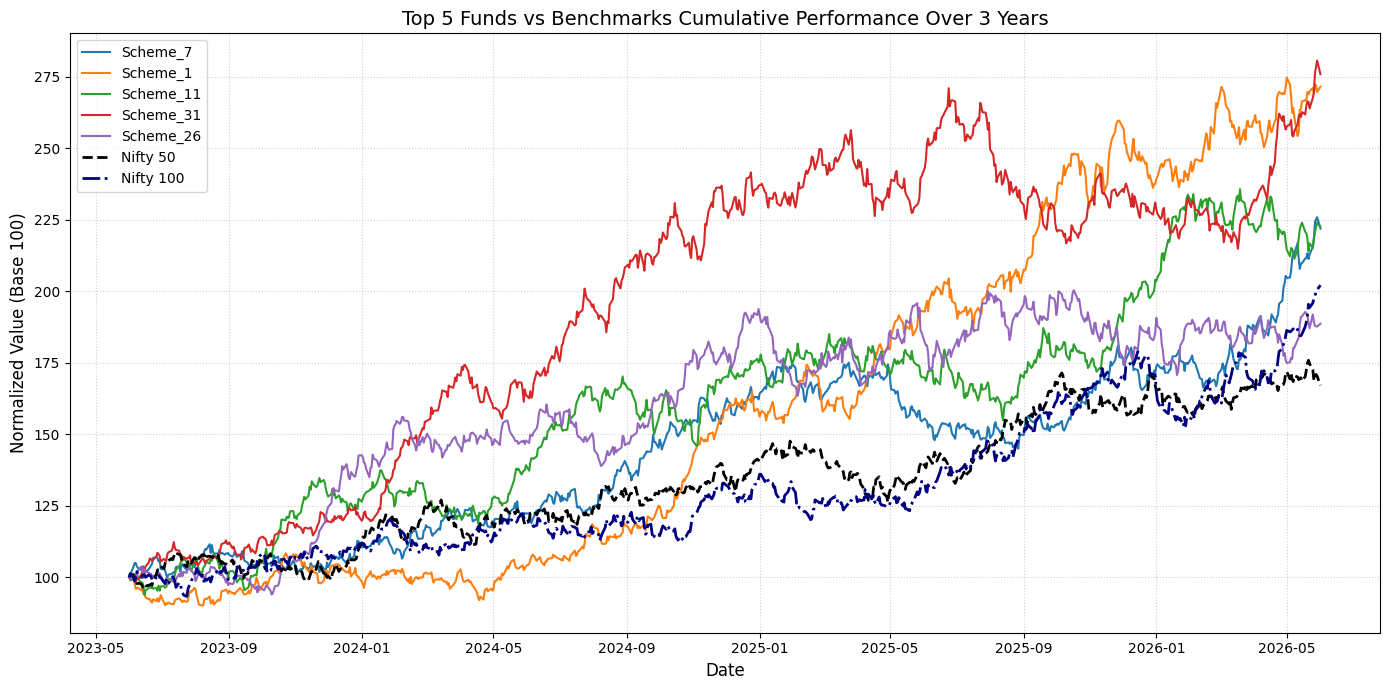

In [37]:
# Task 8: Benchmark comparison chart & Tracking Error over 3 Years
top_5_funds = df_scorecard['Scheme_Name'].head(5).tolist()
three_years_ago = df_returns.index.max() - pd.DateOffset(years=3)

# 1. Slice accurate 3-year data
df_nav_3yr = df_nav.loc[three_years_ago:]

# --- DEBUGGING CHECK ---
# Agar ye print 0 dikhata hai, matlab date filtering mein gadbad hai
print(f"Data rows found for plotting: {len(df_nav_3yr)}") 

# 2. Normalize to Base 100
df_nav_normalized = (df_nav_3yr / df_nav_3yr.iloc[0]) * 100

# 3. Explicitly create figure and axes
fig, ax = plt.subplots(figsize=(14, 7))

# 4. Plot top 5 funds using the explicit axis (ax)
for fund in top_5_funds:
    ax.plot(df_nav_normalized.index, df_nav_normalized[fund], label=f"{fund}")

# 5. Plot Benchmarks
ax.plot(df_nav_normalized.index, df_nav_normalized["Nifty 50"], label="Nifty 50", color="black", linewidth=2, linestyle="--")
ax.plot(df_nav_normalized.index, df_nav_normalized["Nifty 100"], label="Nifty 100", color="navy", linewidth=2, linestyle="-.")

# 6. Formatting titles and labels
ax.set_title("Top 5 Funds vs Benchmarks Cumulative Performance Over 3 Years", fontsize=14)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Normalized Value (Base 100)", fontsize=12)
ax.legend(loc="upper left")
ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

# 7. Save and clear properly
plt.savefig("benchmark_comparison_chart.png", dpi=300)
plt.show()